In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
mf_data = pd.read_csv("../data/combined_mutual_fund_data.csv")

print("Mutual Fund Data Shape:", mf_data.shape)
mf_data.head()

Mutual Fund Data Shape: (2405, 10)


,Year,Month,Scheme_Name,No_of_Schemes,No_of_Folios,Funds_Mobilized,Redemption,Net_Inflow,AUM,AAUM
0,2023,April,Overnight Fund,32.0,659479.0,377180.355063,371073.009946,6107.345117,102344.654705,115719.431400
1,2023,April,Liquid Fund,36.0,1775399.0,312871.766701,249652.436168,63219.330534,397785.671311,426709.747828
2,2023,April,Ultra Short Duration Fund,25.0,632337.0,21919.186766,11256.588603,10662.598163,90295.366968,87453.312922
3,2023,April,Low Duration Fund,21.0,935894.0,11249.143958,5785.890979,5463.252980,92765.186760,89949.112895
4,2023,April,Money Market Fund,22.0,422740.0,31153.725199,17192.768467,13960.956732,122783.890913,119131.924116


In [3]:
direct_equity = pd.read_csv("../data/direct_equity/direct_equity_monthly_data.csv")

print("Direct Equity Data Shape:", direct_equity.shape)
direct_equity.head()

Direct Equity Data Shape: (25, 5)


,Year,Month,BSE_Equity_Value,NSE_Equity_Value,Total_Equity_Settlement_Value
0,2024,August,118735.49,549605.70,668341.19
1,2024,September,116491.49,521852.58,638344.07
2,2024,October,94956.10,418657.13,513613.23
3,2024,November,71132.02,327020.22,398152.24
4,2024,December,86393.67,403962.37,490356.04


In [4]:
print("Mutual Fund Data:")
mf_data.info()

print("\nDirect Equity Data:")
direct_equity.info()

Mutual Fund Data:
<class 'pandas.DataFrame'>
RangeIndex: 2405 entries, 0 to 2404
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             2405 non-null   int64  
 1   Month            2405 non-null   str    
 2   Scheme_Name      2405 non-null   str    
 3   No_of_Schemes    2405 non-null   float64
 4   No_of_Folios     2405 non-null   float64
 5   Funds_Mobilized  2405 non-null   float64
 6   Redemption       2405 non-null   float64
 7   Net_Inflow       2405 non-null   float64
 8   AUM              2405 non-null   float64
 9   AAUM             2405 non-null   float64
dtypes: float64(7), int64(1), str(2)
memory usage: 252.3 KB

Direct Equity Data:
<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Year                           25 non

In [5]:
# 1) Missing value check

print("Mutual Fund Missing Values:")
print(mf_data.isnull().sum())

print("\nDirect Equity Missing Values:")
print(direct_equity.isnull().sum())

Mutual Fund Missing Values:
Year               0
Month              0
Scheme_Name        0
No_of_Schemes      0
No_of_Folios       0
Funds_Mobilized    0
Redemption         0
Net_Inflow         0
AUM                0
AAUM               0
dtype: int64

Direct Equity Missing Values:
Year                             0
Month                            0
BSE_Equity_Value                 0
NSE_Equity_Value                 0
Total_Equity_Settlement_Value    0
dtype: int64


In [6]:
# 2) Missing rows check

missing_rows = mf_data[mf_data["No_of_Schemes"].isnull()]

print("Rows with missing values:", len(missing_rows))
missing_rows[["Year", "Month", "Scheme_Name"]].head(20)

Rows with missing values: 0


,Year,Month,Scheme_Name


In [7]:
# 3) Category/Note rows remove

category_note_rows = [
    "Close Ended Schemes",
    "Interval Schemes"
]

before = len(mf_data)

mf_data = mf_data[
    ~mf_data["Scheme_Name"].astype(str).str.strip().isin(category_note_rows)
].copy()

after = len(mf_data)

print("Rows before cleaning:", before)
print("Rows after cleaning:", after)
print("Rows removed:", before - after)

Rows before cleaning: 2405
Rows after cleaning: 2405
Rows removed: 0


In [8]:
# 4) Check remaining missing rows

remaining_missing = mf_data[mf_data["No_of_Schemes"].isnull()]

print("Remaining missing rows:", len(remaining_missing))

remaining_missing[
    ["Year", "Month", "Scheme_Name"]
].head(30)

Remaining missing rows: 0


,Year,Month,Scheme_Name


In [9]:
# 5) Remaining category/Note rows remove

before = len(mf_data)

mf_data = mf_data[
    ~mf_data["Scheme_Name"].astype(str).str.strip().str.startswith(
        ("Fund of Funds Scheme (Domestic)", "**", "##", "$$")
    )
].copy()

after = len(mf_data)

print("Rows before cleaning:", before)
print("Rows after cleaning:", after)
print("Rows removed:", before - after)

Rows before cleaning: 2405
Rows after cleaning: 2405
Rows removed: 0


In [10]:
print("Remaining missing values:")
print(mf_data.isnull().sum())

Remaining missing values:
Year               0
Month              0
Scheme_Name        0
No_of_Schemes      0
No_of_Folios       0
Funds_Mobilized    0
Redemption         0
Net_Inflow         0
AUM                0
AAUM               0
dtype: int64


In [13]:
# 6) remove 'Sr'

print("Updated Shape:", mf_data.shape)
print("\nColumns:")
print(mf_data.columns.tolist())

Updated Shape: (2405, 10)

Columns:
['Year', 'Month', 'Scheme_Name', 'No_of_Schemes', 'No_of_Folios', 'Funds_Mobilized', 'Redemption', 'Net_Inflow', 'AUM', 'AAUM']


In [14]:
# 7) Describe()

print("Mutual Fund Statistical Summary:")
mf_data.describe()


Mutual Fund Statistical Summary:


,Year,No_of_Schemes,No_of_Folios,Funds_Mobilized,Redemption,Net_Inflow,AUM,AAUM
count,2405.000000,2405.000000,2.405000e+03,2.405000e+03,2.405000e+03,2405.000000,2.405000e+03,2.405000e+03
mean,2023.446154,117.066944,1.286877e+07,7.592483e+04,7.400100e+04,1923.824927,3.871376e+05,3.935021e+05
std,1.571146,298.723487,3.827165e+07,2.452158e+05,2.440774e+05,26911.213836,1.092297e+06,1.109029e+06
min,2020.000000,0.000000,0.000000e+00,-1.085388e+04,-1.493182e+04,-294987.175868,0.000000e+00,0.000000e+00
25%,2023.000000,17.000000,2.466870e+05,2.419748e+02,2.404649e+02,-156.493185,2.107364e+04,2.090717e+04
50%,2024.000000,25.000000,8.682200e+05,2.082070e+03,1.653753e+03,134.859815,7.816994e+04,8.047108e+04
75%,2025.000000,42.000000,7.259960e+06,9.380484e+03,6.899375e+03,2127.786748,2.227097e+05,2.275839e+05
max,2026.000000,1958.000000,2.739343e+08,1.561579e+06,1.801489e+06,239906.793902,8.202956e+06,8.342617e+06


In [15]:
print("Direct Equity Statistical Summary:")
direct_equity.describe()

Direct Equity Statistical Summary:


,Year,BSE_Equity_Value,NSE_Equity_Value,Total_Equity_Settlement_Value
count,25.000000,25.000000,25.000000,25.000000
mean,2025.120000,94545.733119,422055.684110,516601.417229
std,0.725718,16761.244656,85701.751267,99523.590280
min,2024.000000,55814.440000,243120.100000,298934.540000
25%,2025.000000,83435.240000,360320.910000,448251.150000
50%,2025.000000,97781.930000,425754.460000,526324.520000
75%,2026.000000,104039.388330,496056.420000,592172.460000
max,2026.000000,118735.490000,550931.390300,668341.190000


In [16]:
# 8) Check data types

print("Mutual Fund Data Types:")
print(mf_data.dtypes)

print("\nDirect Equity Data Types:")
print(direct_equity.dtypes)

Mutual Fund Data Types:
Year                 int64
Month                  str
Scheme_Name            str
No_of_Schemes      float64
No_of_Folios       float64
Funds_Mobilized    float64
Redemption         float64
Net_Inflow         float64
AUM                float64
AAUM               float64
dtype: object

Direct Equity Data Types:
Year                               int64
Month                                str
BSE_Equity_Value                 float64
NSE_Equity_Value                 float64
Total_Equity_Settlement_Value    float64
dtype: object


In [17]:
# 9) Check duplicates records

print("Mutual Fund Duplicate Rows:", mf_data.duplicated().sum())

print("Direct Equity Duplicate Rows:", direct_equity.duplicated().sum())

Mutual Fund Duplicate Rows: 0
Direct Equity Duplicate Rows: 0


In [18]:
# 10) Remove duplicates records

before = len(mf_data)

mf_data = mf_data.drop_duplicates().copy()

after = len(mf_data)

print("Rows before removing duplicates:", before)
print("Rows after removing duplicates:", after)
print("Duplicate rows removed:", before - after)

Rows before removing duplicates: 2405
Rows after removing duplicates: 2405
Duplicate rows removed: 0


In [19]:
print("Remaining Mutual Fund Duplicates:", mf_data.duplicated().sum())

Remaining Mutual Fund Duplicates: 0


In [20]:
# 11) check final shape
print("Mutual Fund Data Shape:", mf_data.shape)
print("Direct Equity Data Shape:", direct_equity.shape)

Mutual Fund Data Shape: (2405, 10)
Direct Equity Data Shape: (25, 5)


In [21]:
# 12) Mutual Fund-Basic numerical summary
print("Mutual Fund Summary:")
print(mf_data.describe())

Mutual Fund Summary:
              Year  No_of_Schemes  No_of_Folios  Funds_Mobilized  \
count  2405.000000    2405.000000  2.405000e+03     2.405000e+03   
mean   2023.446154     117.066944  1.286877e+07     7.592483e+04   
std       1.571146     298.723487  3.827165e+07     2.452158e+05   
min    2020.000000       0.000000  0.000000e+00    -1.085388e+04   
25%    2023.000000      17.000000  2.466870e+05     2.419748e+02   
50%    2024.000000      25.000000  8.682200e+05     2.082070e+03   
75%    2025.000000      42.000000  7.259960e+06     9.380484e+03   
max    2026.000000    1958.000000  2.739343e+08     1.561579e+06   

         Redemption     Net_Inflow           AUM          AAUM  
count  2.405000e+03    2405.000000  2.405000e+03  2.405000e+03  
mean   7.400100e+04    1923.824927  3.871376e+05  3.935021e+05  
std    2.440774e+05   26911.213836  1.092297e+06  1.109029e+06  
min   -1.493182e+04 -294987.175868  0.000000e+00  0.000000e+00  
25%    2.404649e+02    -156.493185  2.107

In [22]:
# 13) Year-wise Mutual Fund Analysis
yearly_aum = mf_data.groupby("Year")["AUM"].mean()

print("Year-wise Average AUM:")
print(yearly_aum)

Year-wise Average AUM:
Year
2020    187485.223440
2021    222777.524938
2022    269366.225492
2023    317751.920633
2024    444897.265262
2025    516009.128142
2026    563752.225661
Name: AUM, dtype: float64


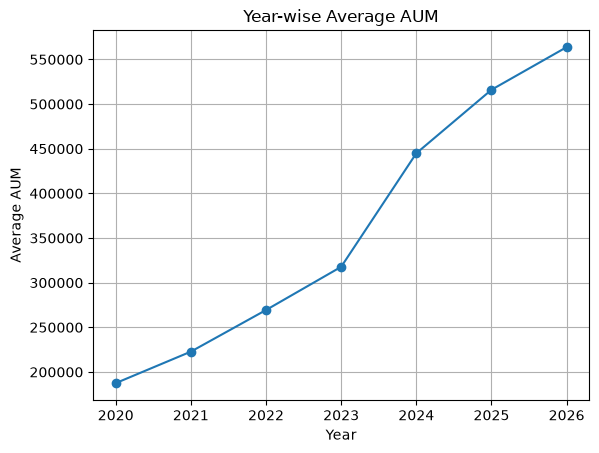

In [23]:
# 14) Year wise Chart (Line chart)
yearly_aum.plot(kind="line", marker="o")

plt.title("Year-wise Average AUM")
plt.xlabel("Year")
plt.ylabel("Average AUM")
plt.grid()
plt.show()

In [24]:
# 14) Year-wise Average Net Inflow
yearly_inflow = mf_data.groupby("Year")["Net_Inflow"].mean()

print("Year-wise Average Net Inflow:")
print(yearly_inflow)

Year-wise Average Net Inflow:
Year
2020   -2279.041820
2021   -1455.379802
2022     -75.921776
2023    1633.330660
2024    3459.948900
2025    4326.617040
2026     263.779405
Name: Net_Inflow, dtype: float64


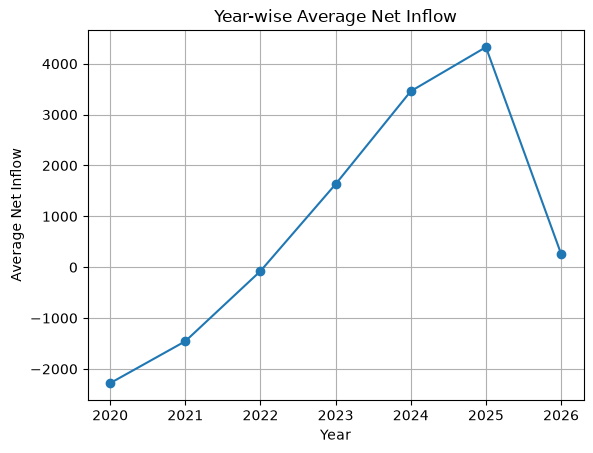

In [25]:
# 15) Year-wise Average Net Inflow Chart
yearly_inflow.plot(kind="line", marker="o")

plt.title("Year-wise Average Net Inflow")
plt.xlabel("Year")
plt.ylabel("Average Net Inflow")
plt.grid()
plt.show()

In [26]:
# 16) Month-wise Average AUM
monthly_aum = mf_data.groupby("Month")["AUM"].mean()

print("Month-wise Average AUM:")
print(monthly_aum)

Month-wise Average AUM:
Month
April        297237.109335
August       448862.964789
December     420379.716891
February     344746.299047
January      344739.813536
July         444522.902856
June         428457.462774
March        330989.105702
May          412131.772609
November     418315.691774
October      461548.228286
September    450669.232199
Name: AUM, dtype: float64


In [27]:
# 17) Arrange months in correct order
months = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_aum = monthly_aum.reindex(months)

print(monthly_aum)

Month
January      344739.813536
February     344746.299047
March        330989.105702
April        297237.109335
May          412131.772609
June         428457.462774
July         444522.902856
August       448862.964789
September    450669.232199
October      461548.228286
November     418315.691774
December     420379.716891
Name: AUM, dtype: float64


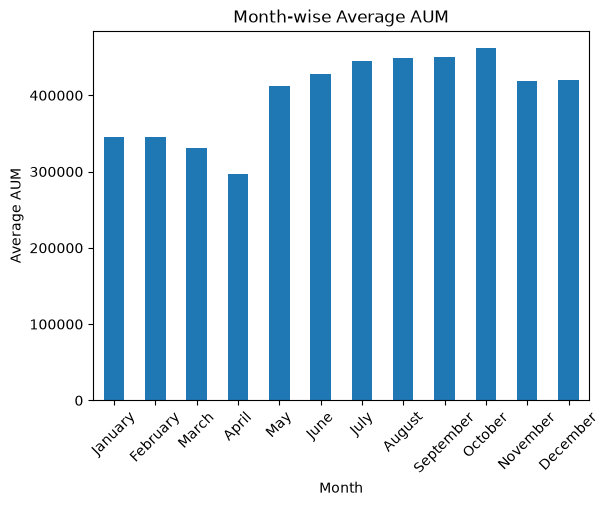

In [28]:
# 18) Month-wise Average AUM Chart
monthly_aum.plot(kind="bar")

plt.title("Month-wise Average AUM")
plt.xlabel("Month")
plt.ylabel("Average AUM")
plt.xticks(rotation=45)
plt.show()

In [29]:
# 19) Year-wise Direct Equity Analysis
yearly_equity = direct_equity.groupby("Year")["Total_Equity_Settlement_Value"].mean()

print("Year-wise Average Equity Settlement Value:")
print(yearly_equity)

Year-wise Average Equity Settlement Value:
Year
2024    541761.354000
2025    459705.281667
2026    586220.660090
Name: Total_Equity_Settlement_Value, dtype: float64


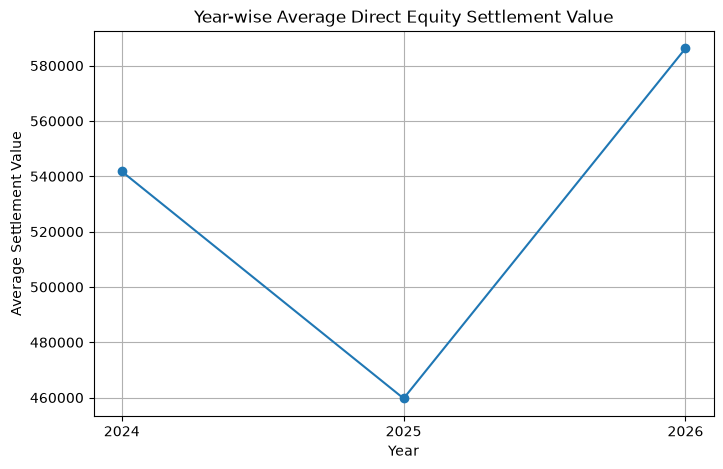

In [30]:
# 20) Year-wise Direct Equity Trend
plt.figure(figsize=(8, 5))

yearly_equity.plot(kind="line", marker="o")

plt.title("Year-wise Average Direct Equity Settlement Value")
plt.xlabel("Year")
plt.ylabel("Average Settlement Value")

plt.xticks([2024, 2025, 2026])

plt.grid()
plt.show()

In [31]:
# 21) BSE vs NSE Comparison
bse_nse = direct_equity[["BSE_Equity_Value", "NSE_Equity_Value"]].mean()

print("Average BSE Equity Value:", bse_nse["BSE_Equity_Value"])
print("Average NSE Equity Value:", bse_nse["NSE_Equity_Value"])

Average BSE Equity Value: 94545.73311922
Average NSE Equity Value: 422055.684109692


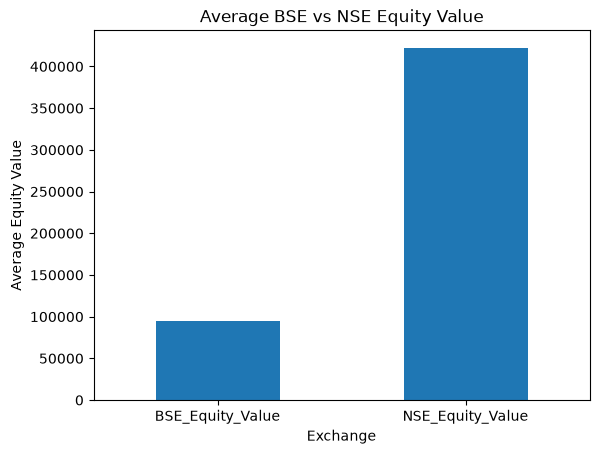

In [32]:
# 22) BSE vs NSE Average Equity Value
bse_nse.plot(kind="bar")

plt.title("Average BSE vs NSE Equity Value")
plt.xlabel("Exchange")
plt.ylabel("Average Equity Value")
plt.xticks(rotation=0)
plt.show()

In [33]:
# 23) Mutual Fund vs Direct Equity - Year-wise Trend Data
mf_yearly = mf_data.groupby("Year")["AUM"].mean()

equity_yearly = direct_equity.groupby("Year")["Total_Equity_Settlement_Value"].mean()

comparison = pd.DataFrame({
    "Mutual_Fund_AUM": mf_yearly,
    "Direct_Equity_Value": equity_yearly
})

print(comparison)

      Mutual_Fund_AUM  Direct_Equity_Value
Year                                      
2020    187485.223440                  NaN
2021    222777.524938                  NaN
2022    269366.225492                  NaN
2023    317751.920633                  NaN
2024    444897.265262        541761.354000
2025    516009.128142        459705.281667
2026    563752.225661        586220.660090


In [34]:
# 24) Common Years and Trend Index
comparison = comparison.loc[[2024, 2025, 2026]]

comparison["MF_Index"] = (
    comparison["Mutual_Fund_AUM"] / comparison["Mutual_Fund_AUM"].iloc[0]
) * 100

comparison["Equity_Index"] = (
    comparison["Direct_Equity_Value"] / comparison["Direct_Equity_Value"].iloc[0]
) * 100

print(comparison)

      Mutual_Fund_AUM  Direct_Equity_Value    MF_Index  Equity_Index
Year                                                                
2024    444897.265262        541761.354000  100.000000    100.000000
2025    516009.128142        459705.281667  115.983884     84.853834
2026    563752.225661        586220.660090  126.715147    108.206437


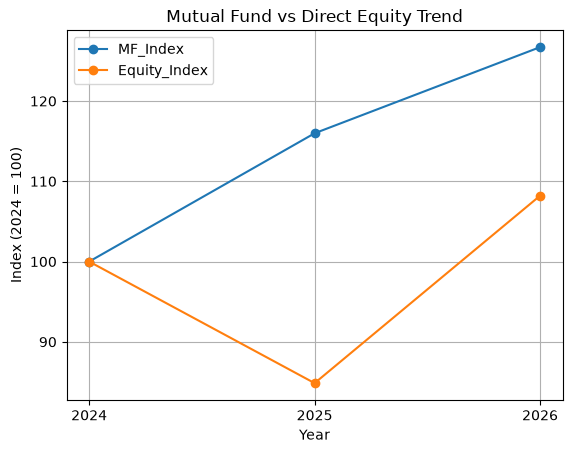

In [35]:
# 25) Mutual Fund vs Direct Equity Trend Comparison

comparison[["MF_Index", "Equity_Index"]].plot(
    kind="line",
    marker="o"
)

plt.title("Mutual Fund vs Direct Equity Trend")
plt.xlabel("Year")
plt.ylabel("Index (2024 = 100)")
plt.xticks([2024, 2025, 2026])
plt.grid()

plt.savefig("comparison_chart.png")

plt.show()

In [36]:
# 26) Top 10 Schemes by Average AUM
top_schemes = (
    mf_data.groupby("Scheme_Name")["AUM"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Schemes by Average AUM:")
print(top_schemes)

Top 10 Schemes by Average AUM:
Scheme_Name
Grand Total                                                              5.543048e+06
Total A-Open ended Schemes                                               5.364356e+06
Grand Total (A + B + C)                                                  2.754371e+06
Sub Total - II (i+ii+iii+iv+v+vi+vii+viii+ix+x+xi)                       2.369296e+06
Sub Total - I (i+ii+iii+iv+v+vi+vii+viii+ix+x+xi+xii+xiii+xiv+xv+xvi)    1.510982e+06
Sub Total - I (1+2+3+4+5+6+7+8+9+10+11+12+13+14+15+16)                   1.164401e+06
Sub Total - V (i+ii+iii+iv)                                              9.366872e+05
Sub Total - III (i+ii+iii+iv+v+vi)                                       7.263393e+05
Sub Total - II (17+18+19+20+21+22+23+24+25+26)                           7.083943e+05
Other ETFs                                                               6.191244e+05
Name: AUM, dtype: float64


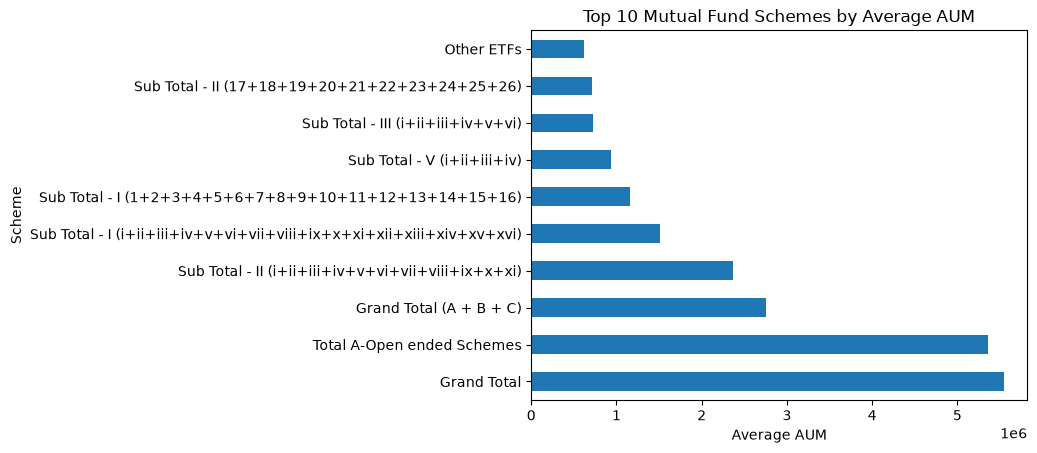

In [37]:
# 27) Top 10 Mutual Fund Schemes - AUM Chart
top_schemes.plot(kind="barh")

plt.title("Top 10 Mutual Fund Schemes by Average AUM")
plt.xlabel("Average AUM")
plt.ylabel("Scheme")
plt.show()

In [38]:
# 28) Positive and Negative Net Inflow
positive_inflow = (mf_data["Net_Inflow"] > 0).sum()
negative_inflow = (mf_data["Net_Inflow"] < 0).sum()

print("Positive Net Inflow:", positive_inflow)
print("Negative Net Inflow:", negative_inflow)

Positive Net Inflow: 1402
Negative Net Inflow: 879


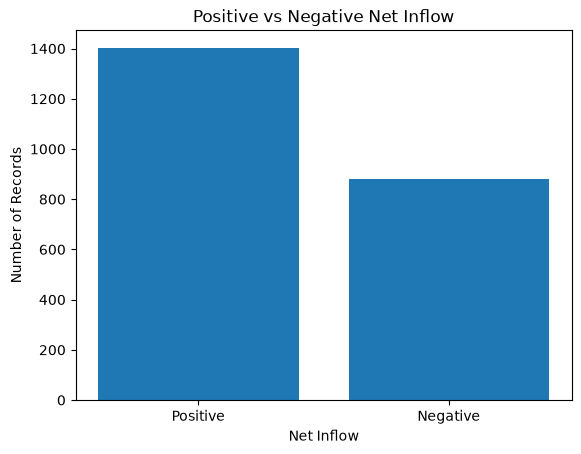

In [39]:
# 29) Positive vs Negative Net Inflow Chart
inflow_data = [positive_inflow, negative_inflow]

plt.bar(["Positive", "Negative"], inflow_data)

plt.title("Positive vs Negative Net Inflow")
plt.xlabel("Net Inflow")
plt.ylabel("Number of Records")

plt.show()

In [40]:
# Save cleaned mutual fund data

mf_data.to_csv("../data/combined_mutual_fund_data.csv", index=False)

print("Cleaned data saved successfully")

Cleaned data saved successfully


In [41]:
!pip install reportlab